# GAN Run Visualizer (Prediction vs Ground Truth)

This notebook inspects the latest saved GAN run outputs, shows checkpoint-level metrics, and visualizes **input / prediction / target** side by side with error maps.

It is designed to run either in this repo or in Colab after syncing the same folder structure.

In [1]:
# Install deps only if missing
import importlib, subprocess, sys
for pkg, imp in [("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"), ("PIL", "PIL"), ("skimage", "skimage")]:
    try:
        importlib.import_module(imp)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])
print("Dependencies ready")

Dependencies ready


In [21]:
from pathlib import Path
import json
import random
import re
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity
from google.colab import drive

# ====== Configure paths ======
drive.mount('/content/drive')

RUN_ROOT = Path('/content/drive/MyDrive/Cobas/gan_run')

METRICS_JSON = RUN_ROOT / 'deliverables/cobas_cycle_gan_clean_v1/metrics.json'
RUN_CONFIG_JSON = RUN_ROOT / 'run_config.json'
BENCHMARK_SCRIPT = Path('Full_Paper/Pipeline/Preprocessing/GAN_benchmark_suite.py')

# Optionally override these if your Colab paths differ
EVAL_INPUT_DIR_OVERRIDE = None
EVAL_TARGET_DIR_OVERRIDE = None
# =============================

print('RUN_ROOT:', RUN_ROOT.exists())
print('METRICS_JSON exists:', METRICS_JSON.exists())
print('RUN_CONFIG_JSON exists:', RUN_CONFIG_JSON.exists())
print('BENCHMARK_SCRIPT exists:', BENCHMARK_SCRIPT.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUN_ROOT: True
METRICS_JSON exists: True
RUN_CONFIG_JSON exists: True
BENCHMARK_SCRIPT exists: False


In [22]:
with open(METRICS_JSON, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

with open(RUN_CONFIG_JSON, 'r', encoding='utf-8') as f:
    run_cfg = json.load(f)

BEST_CHECKPOINT = metrics.get('best_checkpoint', 'epoch_0010')
TEST_OUTPUT_DIR = RUN_ROOT / f'results/cobas_clean_v1/test_outputs/{BEST_CHECKPOINT}'

print('Best checkpoint:', BEST_CHECKPOINT)
print('Training epochs:', metrics.get('training_epochs'))
print('Dataset:', metrics.get('dataset'))
print('TEST_OUTPUT_DIR:', TEST_OUTPUT_DIR)

best = metrics['best_metrics']
display(pd.DataFrame([best]).T.rename(columns={0: 'value'}))

Best checkpoint: epoch_0010
Training epochs: 20
Dataset: {'total_frames': 407, 'train_frames': 326, 'test_frames': 81, 'test_ratio': 0.2, 'seed': 42}
TEST_OUTPUT_DIR: /content/drive/MyDrive/Cobas/gan_run/results/cobas_clean_v1/test_outputs/epoch_0010


,value
checkpoint,epoch_0010
n_test,81
MAE_mean,0.030366
MSE_mean,0.003614
RMSE_mean,0.057436
PSNR_mean,25.336015
PSNR_std,3.198017
SSIM_mean,0.840263
SSIM_std,0.035014
elapsed_sec,108.266405


In [23]:
# Regenerate prediction images for BEST_CHECKPOINT if missing
# This creates aligned files like 000123_input.png / _pred.png / _target.png

def count_complete_triplets(folder):
    pat = re.compile(r'^(\d+)_(input|pred|target)\.png$')
    idx = {}
    if not folder.exists():
        return 0
    for p in folder.glob('*.png'):
        m = pat.match(p.name)
        if m:
            sid, kind = m.groups()
            idx.setdefault(sid, set()).add(kind)
    return sum(1 for kinds in idx.values() if kinds == {'input','pred','target'})

triplet_count = count_complete_triplets(TEST_OUTPUT_DIR)
print(f'Existing triplets in {TEST_OUTPUT_DIR}:', triplet_count)

if triplet_count == 0:
    if not BENCHMARK_SCRIPT.exists():
        raise FileNotFoundError(f'Benchmark script not found: {BENCHMARK_SCRIPT}')

    eval_input_dir = Path(EVAL_INPUT_DIR_OVERRIDE) if EVAL_INPUT_DIR_OVERRIDE else Path(run_cfg['optical_frames'])
    eval_target_dir = Path(EVAL_TARGET_DIR_OVERRIDE) if EVAL_TARGET_DIR_OVERRIDE else Path(run_cfg['thermal_frames'])

    if not eval_input_dir.exists() or not eval_target_dir.exists():
        raise FileNotFoundError(
            'Input/target frame folders not found. Set EVAL_INPUT_DIR_OVERRIDE and EVAL_TARGET_DIR_OVERRIDE.'
        )

    ckpt_path = RUN_ROOT / 'checkpoints' / f'{BEST_CHECKPOINT}.pt'
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint missing: {ckpt_path}')

    TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    bench_json = RUN_ROOT / f'results/cobas_clean_v1/benchmark_{BEST_CHECKPOINT}.json'

    cmd = [
        sys.executable, str(BENCHMARK_SCRIPT),
        '--model', str(ckpt_path),
        '--input-dir', str(eval_input_dir),
        '--target-dir', str(eval_target_dir),
        '--direction', 'o2t',
        '--image-size', str(run_cfg.get('image_size', 256)),
        '--batch-size', '8',
        '--num-workers', str(run_cfg.get('num_workers', 2)),
        '--val-ratio', str(metrics.get('dataset', {}).get('test_ratio', 0.2)),
        '--seed', str(metrics.get('dataset', {}).get('seed', 42)),
        '--save-preds-dir', str(TEST_OUTPUT_DIR),
        '--output-json', str(bench_json),
    ]

    print('Running benchmark to generate visualization outputs...')
    print(' '.join(cmd))
    subprocess.run(cmd, check=True)

    triplet_count = count_complete_triplets(TEST_OUTPUT_DIR)
    print('Generated triplets:', triplet_count)
    print('Benchmark JSON:', bench_json)
else:
    print('Using existing saved outputs for best checkpoint.')

Existing triplets in /content/drive/MyDrive/Cobas/gan_run/results/cobas_clean_v1/test_outputs/epoch_0010: 81
Using existing saved outputs for best checkpoint.


In [24]:
# Plot checkpoint trends from metrics.json
all_ckpt = metrics.get('all_checkpoints', {})
df_ckpt = pd.DataFrame(all_ckpt).T
df_ckpt.index.name = 'checkpoint'
df_ckpt = df_ckpt.reset_index()
df_ckpt['epoch_num'] = df_ckpt['checkpoint'].str.extract(r'(\d+)').astype(int)
df_ckpt = df_ckpt.sort_values('epoch_num')
display(df_ckpt[['checkpoint','PSNR_mean','SSIM_mean','MAE_mean','RMSE_mean']])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(df_ckpt['epoch_num'], df_ckpt['SSIM_mean'], marker='o', label='SSIM')
axs[0].plot(df_ckpt['epoch_num'], df_ckpt['PSNR_mean']/30.0, marker='s', label='PSNR/30')
axs[0].set_title('Quality trend by checkpoint')
axs[0].set_xlabel('Epoch checkpoint')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(df_ckpt['epoch_num'], df_ckpt['MAE_mean'], marker='o', label='MAE')
axs[1].plot(df_ckpt['epoch_num'], df_ckpt['RMSE_mean'], marker='s', label='RMSE')
axs[1].set_title('Error trend by checkpoint')
axs[1].set_xlabel('Epoch checkpoint')
axs[1].legend()
axs[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: cannot insert checkpoint, already exists

In [25]:
# Build aligned triplets from saved outputs
pat = re.compile(r'^(\d+)_(input|pred|target)\.png$')
idx = {}
for p in TEST_OUTPUT_DIR.glob('*.png'):
    m = pat.match(p.name)
    if not m:
        continue
    sid, kind = m.groups()
    idx.setdefault(sid, {})[kind] = p

triplets = []
for sid, row in idx.items():
    if {'input','pred','target'}.issubset(row):
        triplets.append((sid, row['input'], row['pred'], row['target']))

triplets = sorted(triplets, key=lambda x: int(x[0]))
print('Triplets found:', len(triplets))
print('Unique ids with any file:', len(idx))
print('Example ids:', [t[0] for t in triplets[:8]])

Triplets found: 81
Unique ids with any file: 81
Example ids: ['000002', '000009', '000011', '000026', '000029', '000031', '000034', '000038']


In [26]:
def load_img01(path):
    arr = np.asarray(Image.open(path).convert('RGB')).astype(np.float32) / 255.0
    return arr

def img_metrics(pred, target):
    err = pred - target
    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    psnr = float(20.0 * np.log10(1.0 / (np.sqrt(mse) + 1e-12)))
    ssim = float(structural_similarity(target, pred, data_range=1.0, channel_axis=2))
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'PSNR': psnr, 'SSIM': ssim}

rows = []
for sid, p_in, p_pred, p_tgt in triplets:
    pred = load_img01(p_pred)
    tgt = load_img01(p_tgt)
    m = img_metrics(pred, tgt)
    rows.append({'id': int(sid), **m, 'input': str(p_in), 'pred': str(p_pred), 'target': str(p_tgt)})

df_img = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
display(df_img.head())

print('Per-image metric summary on saved visualization set:')
display(df_img[['MAE','RMSE','PSNR','SSIM']].describe().T)

print('Reference full-test metric from metrics.json (epoch_0005):')
ref = metrics['all_checkpoints'].get('epoch_0005', {})
print({k: ref.get(k) for k in ['MAE_mean','RMSE_mean','PSNR_mean','SSIM_mean']})

,id,MAE,MSE,RMSE,PSNR,SSIM,input,pred,target
0,2,0.026286,0.002012,0.044855,26.963854,0.864046,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...
1,9,0.029348,0.002860,0.053481,25.435952,0.847638,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...
2,11,0.030059,0.003070,0.055403,25.129262,0.843146,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...
3,26,0.030187,0.003169,0.056296,24.990455,0.837931,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...
4,29,0.029956,0.003199,0.056559,24.949963,0.840201,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...,/content/drive/MyDrive/Cobas/gan_run/results/c...


Per-image metric summary on saved visualization set:


,count,mean,std,min,25%,50%,75%,max
MAE,81.0,0.030338,0.006820,0.017634,0.024288,0.032167,0.034549,0.047843
RMSE,81.0,0.057448,0.017845,0.024126,0.041798,0.062082,0.069677,0.097862
PSNR,81.0,25.333475,3.215633,20.187746,23.138272,24.140618,27.576891,32.350376
SSIM,81.0,0.839302,0.035208,0.790250,0.812994,0.825681,0.869038,0.909801


Reference full-test metric from metrics.json (epoch_0005):
{'MAE_mean': 0.03583665985476087, 'RMSE_mean': 0.06406912680424517, 'PSNR_mean': 24.081655900301215, 'SSIM_mean': 0.7869326442848017}


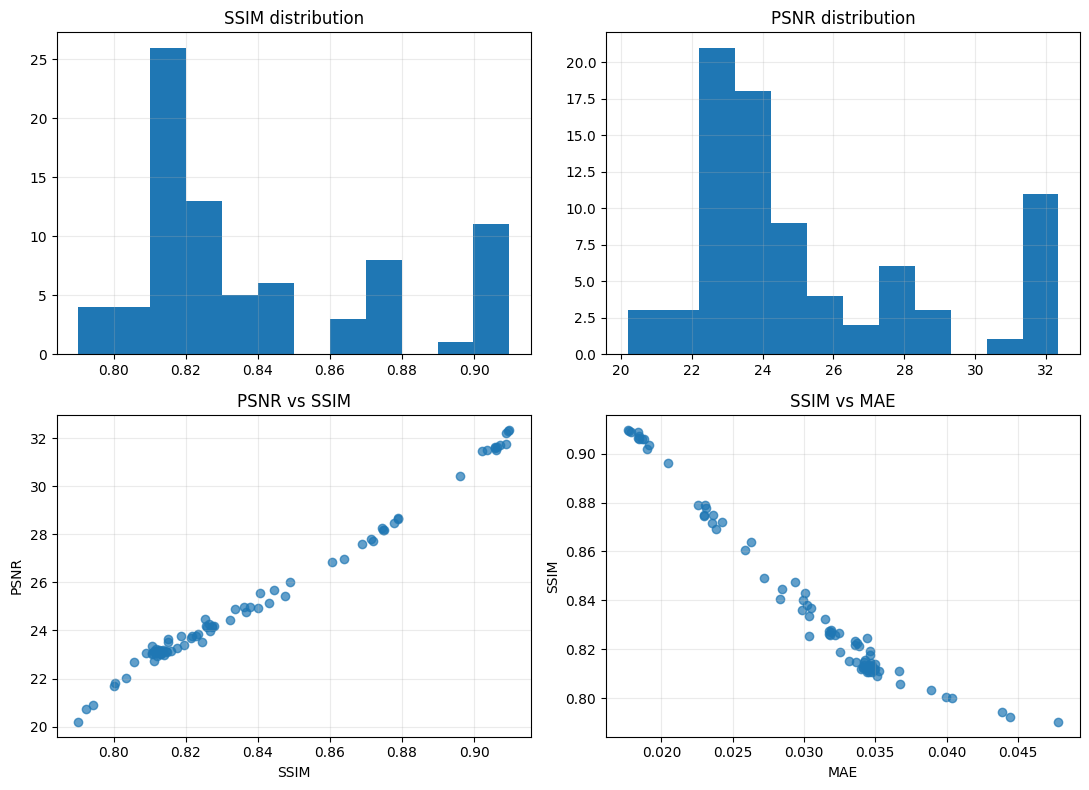

In [27]:
# Distributions and correlations
fig, axs = plt.subplots(2, 2, figsize=(11, 8))
axs[0,0].hist(df_img['SSIM'], bins=12)
axs[0,0].set_title('SSIM distribution')
axs[0,1].hist(df_img['PSNR'], bins=12)
axs[0,1].set_title('PSNR distribution')
axs[1,0].scatter(df_img['SSIM'], df_img['PSNR'], alpha=0.7)
axs[1,0].set_xlabel('SSIM')
axs[1,0].set_ylabel('PSNR')
axs[1,0].set_title('PSNR vs SSIM')
axs[1,1].scatter(df_img['MAE'], df_img['SSIM'], alpha=0.7)
axs[1,1].set_xlabel('MAE')
axs[1,1].set_ylabel('SSIM')
axs[1,1].set_title('SSIM vs MAE')
for ax in axs.ravel():
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [28]:
def show_triplet(row, figsize=(12, 3.8)):
    inp = load_img01(row['input'])
    pred = load_img01(row['pred'])
    tgt = load_img01(row['target'])
    diff = np.abs(pred - tgt).mean(axis=2)

    fig, axs = plt.subplots(1, 4, figsize=figsize)
    axs[0].imshow(inp); axs[0].set_title(f"Input #{int(row['id'])}")
    axs[1].imshow(pred); axs[1].set_title('Prediction')
    axs[2].imshow(tgt); axs[2].set_title('Target (real)')
    im = axs[3].imshow(diff, cmap='magma'); axs[3].set_title('Abs error map')
    for ax in axs:
        ax.axis('off')
    cbar = fig.colorbar(im, ax=axs[3], fraction=0.046, pad=0.04)
    cbar.set_label('Mean abs error (per pixel)')
    fig.suptitle(
        f"id={int(row['id'])} | SSIM={row['SSIM']:.4f} | PSNR={row['PSNR']:.2f} | MAE={row['MAE']:.4f}",
        y=1.05
    )
    plt.tight_layout()
    plt.show()

Best example by SSIM:


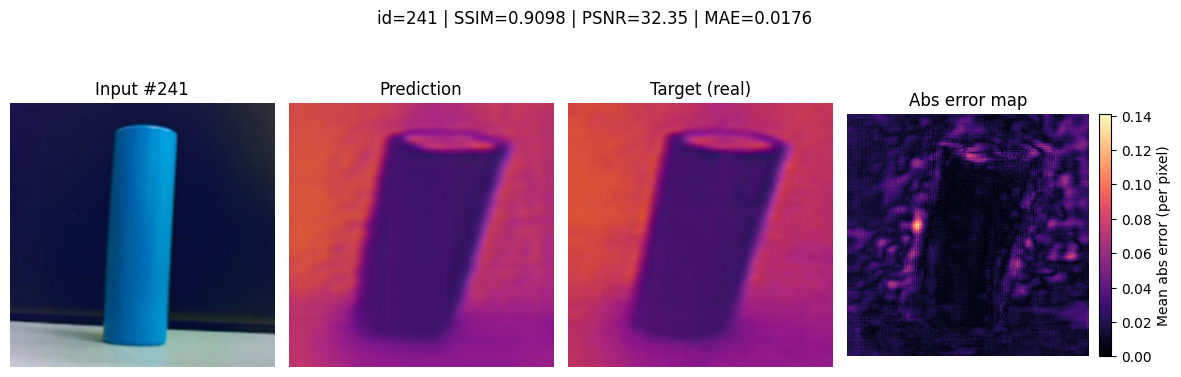

Median example by SSIM:


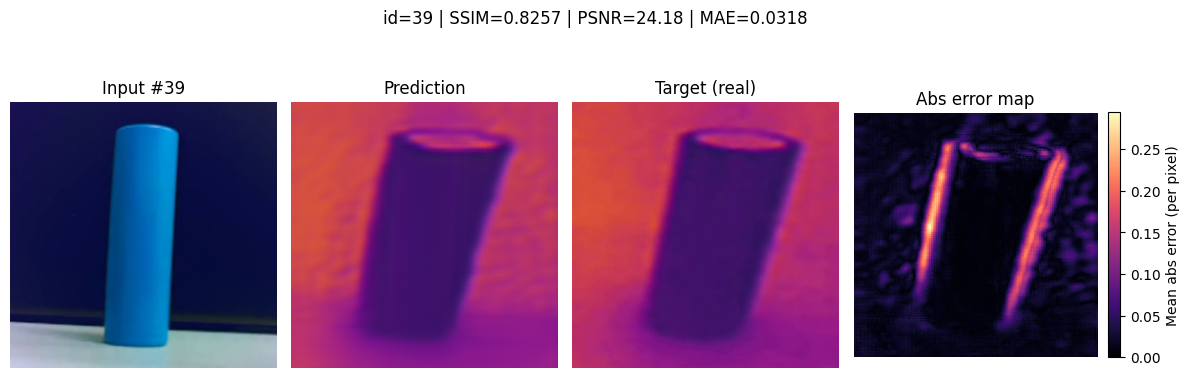

Worst example by SSIM:


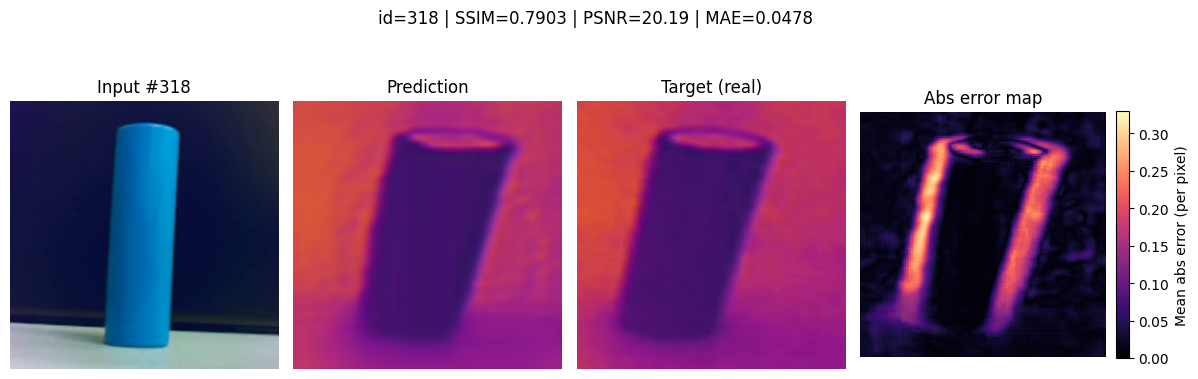

In [29]:
# Show best / median / worst by SSIM
best_row = df_img.sort_values('SSIM', ascending=False).iloc[0]
median_row = df_img.sort_values('SSIM').iloc[len(df_img)//2]
worst_row = df_img.sort_values('SSIM', ascending=True).iloc[0]

print('Best example by SSIM:')
show_triplet(best_row)
print('Median example by SSIM:')
show_triplet(median_row)
print('Worst example by SSIM:')
show_triplet(worst_row)

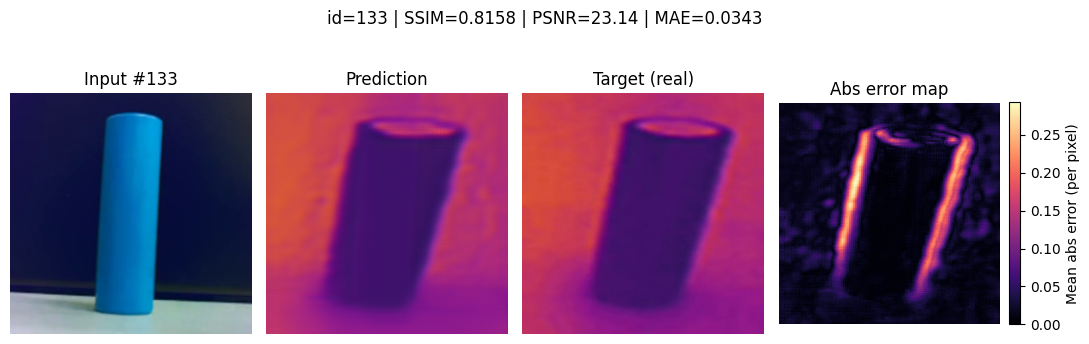

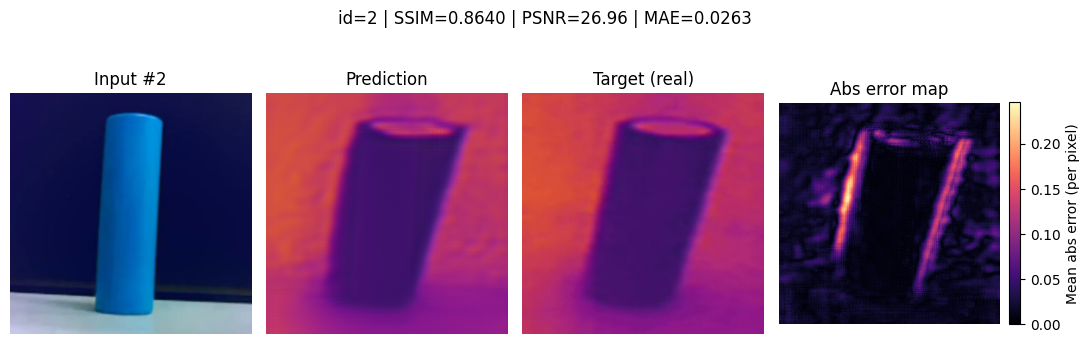

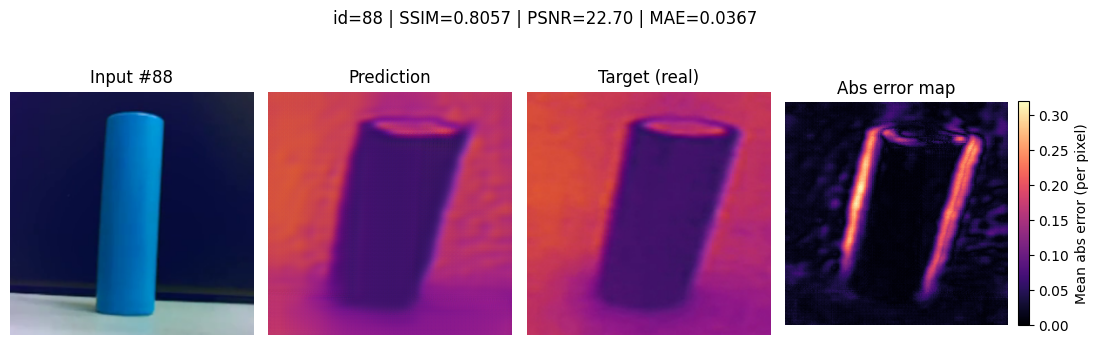

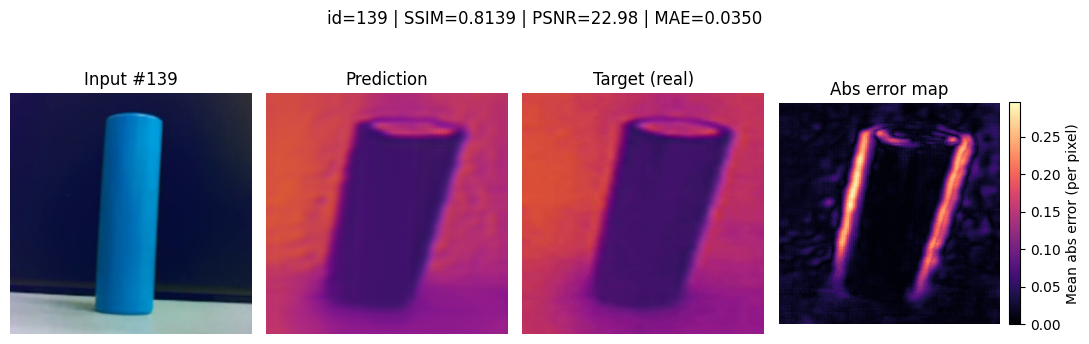

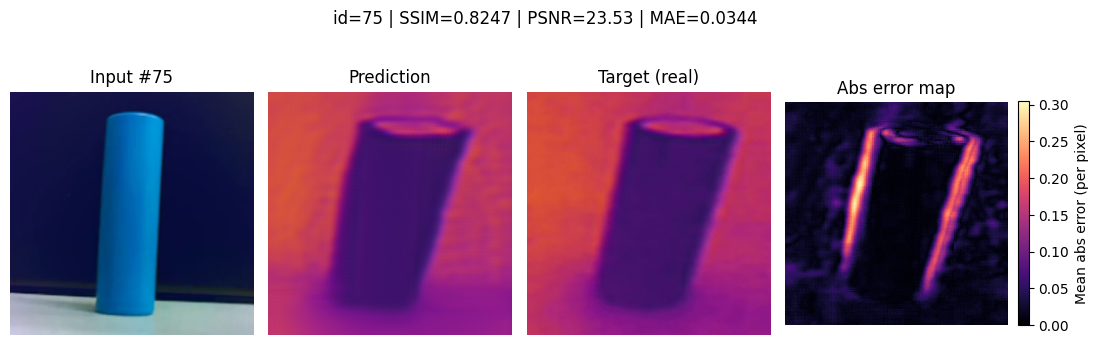

In [30]:
# Inspect random examples
N = 5
sample_rows = df_img.sample(min(N, len(df_img)), random_state=42)
for _, r in sample_rows.iterrows():
    show_triplet(r, figsize=(11, 3.4))